# Wildfire Detection from Aerial Imagery V2

This is the file I used to inspect data and create the functions of the pipeline I later moved into python files to use in different ipynb.




## Setup & Imports

In [1]:
%load_ext autoreload
%autoreload 2


import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Machine Learning libraries (with all necessary imports in each file)
import utils as ml_utils
import config as ml_config
import model as ml_model

# TensorFlow and Keras
import tensorflow as tf
from sklearn.metrics import ( precision_recall_curve, classification_report, precision_score, recall_score, f1_score
)

# Reproducibility
random.seed(ml_config.SEED)
np.random.seed(ml_config.SEED)
tf.random.set_seed(ml_config.SEED)
AUTOTUNE = tf.data.AUTOTUNE


print("TensorFlow:", tf.__version__)


TensorFlow: 2.16.1


## I- Dataset Exploration

In [ ]:
train_counts = ml_utils.count_images(ml_config.TRAIN_DIR)
test_counts  = ml_utils.count_images(ml_config.TEST_DIR)

# Identify lake frames within No_Fire
train_nofire_files = list((ml_config.TRAIN_DIR / "No_Fire").glob("*.jpg"))
n_lake_train = sum(1 for f in train_nofire_files if f.name.startswith("lake"))
n_nofire_train = len(train_nofire_files) - n_lake_train

test_nofire_files  = list((ml_config.TEST_DIR / "No_Fire").glob("*.jpg"))
n_lake_test  = sum(1 for f in test_nofire_files if f.name.startswith("lake"))
n_nofire_test = len(test_nofire_files) - n_lake_test

# Create a summary DataFrame for display
summary = pd.DataFrame({
    "Split":    ["Train", "Train", "Train", "Test", "Test", "Test"],
    "Class":    ["Fire",  "No Fire (non-lake)", "No Fire (lake)",
                 "Fire",  "No Fire (non-lake)", "No Fire (lake)"],
    "Count":    [train_counts["Fire"], n_nofire_train, n_lake_train,
                 test_counts["Fire"],  n_nofire_test,  n_lake_test],
})
print(summary.to_string(index=False))
print(f"\nTotal train: {sum(train_counts.values()):,}  |  Total test: {sum(test_counts.values()):,}")


Split              Class  Count
Train               Fire  25018
Train No Fire (non-lake)   2510
Train     No Fire (lake)  11847
 Test               Fire   5137
 Test No Fire (non-lake)   3480
 Test     No Fire (lake)      0

Total train: 39,375  |  Total test: 8,617


In [ ]:
# obtain file paths for each class
fire_paths  = list((ml_config.TRAIN_DIR / "Fire").glob("*.jpg"))
nofire_paths = [f for f in train_nofire_files if not f.name.startswith("lake")]
lake_paths   = [f for f in train_nofire_files if f.name.startswith("lake")]


## II- Perceptual Deduplication


In [4]:
print("Deduplicating Fire frames …")
fire_sorted   = sorted(fire_paths,   key=ml_utils.frame_number)
fire_deduped  = ml_utils.deduplicate(fire_sorted)

print("Deduplicating No Fire (non-lake) frames …")
nofire_sorted  = sorted(nofire_paths,  key=ml_utils.frame_number)
nofire_deduped = ml_utils.deduplicate(nofire_sorted)

print("Deduplicating Lake frames …")
lake_sorted   = sorted(lake_paths,   key=ml_utils.frame_number)
lake_deduped  = ml_utils.deduplicate(lake_sorted)

print(f"\nFire:    {len(fire_paths):>6,}  →  {len(fire_deduped):>6,}  "
      f"({100*(1-len(fire_deduped)/len(fire_paths)):.1f}% removed)")
print(f"No Fire: {len(nofire_paths):>6,}  →  {len(nofire_deduped):>6,}  "
      f"({100*(1-len(nofire_deduped)/len(nofire_paths)):.1f}% removed)")
print(f"Lake:    {len(lake_paths):>6,}  →  {len(lake_deduped):>6,}  "
      f"({100*(1-len(lake_deduped)/len(lake_paths)):.1f}% removed)")


Deduplicating Fire frames …
Deduplicating No Fire (non-lake) frames …
Deduplicating Lake frames …

Fire:    25,018  →   1,913  (92.4% removed)
No Fire:  2,510  →     566  (77.5% removed)
Lake:    11,847  →     995  (91.6% removed)


## III- Data Preparation


To avoid leakage from temporally correlated frames we split by **frame-number blocks**:
frames are sorted by index, then every 5th contiguous block is assigned to validation.
This ensures no two adjacent frames straddle the boundary differently from a random split.


###  Building the datasets (includes lakes in No_Fire)


Augmentation (applied only during training): horizontal flip, vertical flip, random brightness, random contrast.


In [ ]:
# Build datasets for ternary classification (Fire=0, No Fire=1, Lake=2)
# 10% of lake images are carved out for test before any train/val split
tern_train_ds, tern_val_ds, tern_test_ds, tern_train_labels, tern_val_labels, tern_test_labels = (
    ml_utils.build_ternary_datasets(fire_deduped, nofire_deduped, lake_deduped)
)

# Class weights (to address class imbalance in training set
# so we weight by actual frequency to avoid biasing toward Fire)
n_fire   = tern_train_labels.count(0)
n_nofire = tern_train_labels.count(1)
n_lake   = tern_train_labels.count(2)
total    = n_fire + n_nofire + n_lake

ternary_class_weights = {
    0: total / (3 * n_fire),
    1: total / (3 * n_nofire),
    2: total / (3 * n_lake),
}

print("Ternary class weights:", {k: f"{v:.3f}" for k, v in ternary_class_weights.items()})
print(f"Train batches: {len(tern_train_ds)}  |  val: {len(tern_val_ds)}  |  test: {len(tern_test_ds)}")


Lake  — test: 99  |  train: 768  |  val: 128
Fire  — train: 1640  |  val: 273
No Fire — train: 486  |  val: 80
Ternary class weights: {0: '0.588', 1: '1.985', 2: '1.256'}
Train batches: 91  |  val: 16  |  test: 273


## IV - Ternary Model (V2)

### A) Model Training

In [8]:
micro_cnn_ternary = ml_model.ternary_micro_cnn()
micro_cnn_ternary.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 254, 254, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 127, 127, 8)    │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 127, 127, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 127, 127, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 127, 127, 8)    │            72 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 127, 127, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 127, 127, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 127, 127, 16)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 127, 127, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 63, 63, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 63, 63, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 63, 63, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 31, 31, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,763 (45.95 KB)

 Trainable params: 11,091 (43.32 KB)

 Non-trainable params: 672 (2.62 KB)

In [10]:
history_micro_cnn_ternary = micro_cnn_ternary.fit(
    tern_train_ds,
    validation_data=tern_val_ds,
    epochs=100,
    class_weight=ternary_class_weights,
    callbacks=ml_config.ternary_callbacks,
    verbose=1,
)


Epoch 1/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 184ms/step - accuracy: 0.8238 - loss: 0.4021 - top2_acc: 0.9938 - val_accuracy: 0.5676 - val_loss: 1.0871 - val_top2_acc: 0.7339 - learning_rate: 0.0010
Epoch 2/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 0.8487 - loss: 0.3521 - top2_acc: 0.9938 - val_accuracy: 0.6757 - val_loss: 0.8138 - val_top2_acc: 0.8378 - learning_rate: 0.0010
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step - accuracy: 0.8552 - loss: 0.3322 - top2_acc: 0.9955 - val_accuracy: 0.6674 - val_loss: 0.8595 - val_top2_acc: 0.8337 - learning_rate: 0.0010
Epoch 4/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step - accuracy: 0.8718 - loss: 0.3017 - top2_acc: 0.9962 - val_accuracy: 0.6985 - val_loss: 0.8080 - val_top2_acc: 0.8503 - learning_rate: 0.0010
Epoch 5/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 180ms/step - accuracy: 0.8780 - loss: 0.2885 - top2_acc: 0.9976 - val_accuracy: 0.8212 - val_loss: 0.4333 - val_top2_acc: 0.9543 - learning_rate: 0.0010
Epoch 6/100
91/91 ━━

### B) Training Curves

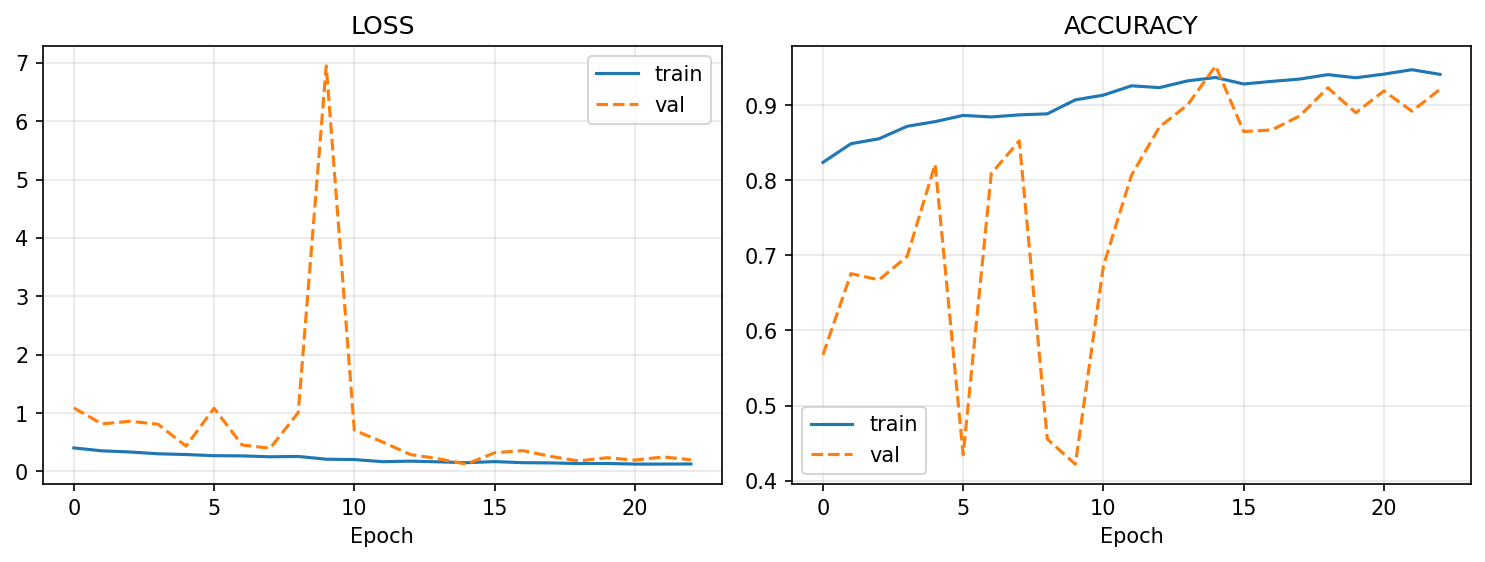

In [36]:
ml_utils.plot_history(history_micro_cnn_ternary, "")


**Comment:** Early stopping monitors `val_accuracy`. Restore best weights is active — the saved model corresponds to the peak val accuracy epoch.

### C) Evaluation

In [14]:
micro_cnn_ternary.evaluate(tern_test_ds, verbose=1)


273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7320 - loss: 0.5697 - top2_acc: 0.9906


[0.5697115659713745, 0.7319871783256531, 0.9905920028686523]

In [33]:
micro_cnn_ternary.evaluate(tern_val_ds, verbose=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9522 - loss: 0.1236 - top2_acc: 1.0000


[0.12355313450098038, 0.952182948589325, 1.0]

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


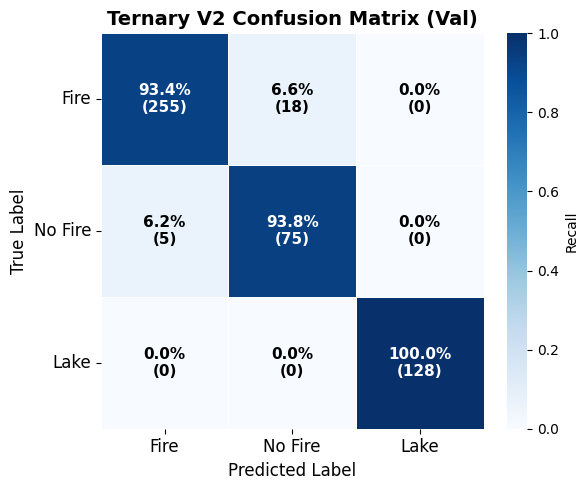

              precision    recall  f1-score   support

        Fire      0.981     0.934     0.957       273
     No Fire      0.806     0.938     0.867        80
        Lake      1.000     1.000     1.000       128

    accuracy                          0.952       481
   macro avg      0.929     0.957     0.941       481
weighted avg      0.957     0.952     0.953       481



In [ ]:
# Analyze val set performance in more detail
val_proba     = micro_cnn_ternary.predict(tern_val_ds)
val_preds_arr = val_proba.argmax(axis=1)
val_true_arr  = np.array(tern_val_labels)

# Plot confusion matrix for val set
ml_utils.plot_confusion_matrix(
    val_true_arr, val_preds_arr,
    class_names=["Fire", "No Fire", "Lake"],
    title="Ternary V2 Confusion Matrix (Val)"
)

# print classification report with 3 decimal places for precision, recall, and F1
print(classification_report(
    val_true_arr, val_preds_arr,
    target_names=["Fire", "No Fire", "Lake"], digits=3
))


273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step


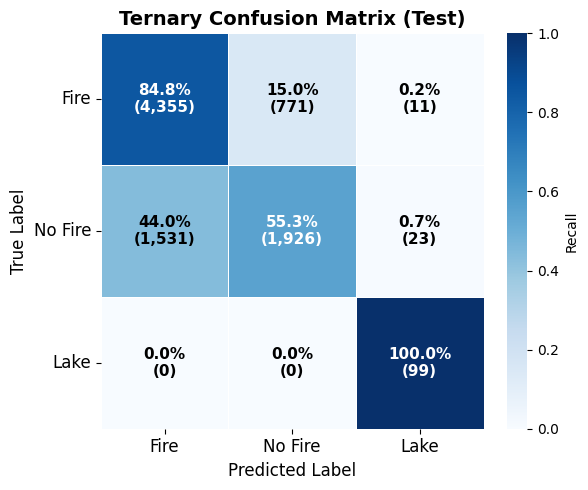

              precision    recall  f1-score   support

        Fire      0.740     0.848     0.790      5137
     No Fire      0.714     0.553     0.624      3480
        Lake      0.744     1.000     0.853        99

    accuracy                          0.732      8716
   macro avg      0.733     0.800     0.756      8716
weighted avg      0.730     0.732     0.724      8716



In [ ]:
# test set performance
test_proba     = micro_cnn_ternary.predict(tern_test_ds)
test_preds_arr = test_proba.argmax(axis=1)
test_true_arr  = np.array(tern_test_labels)

#   Plot confusion matrix for test set
ml_utils.plot_confusion_matrix(
    test_true_arr, test_preds_arr,
    class_names=["Fire", "No Fire", "Lake"],
    title="Ternary Confusion Matrix (Test)"
)

# print classification report with 3 decimal places for precision, recall, and F1
print(classification_report(
    test_true_arr, test_preds_arr,
    target_names=["Fire", "No Fire", "Lake"], digits=3
))


**Comment:** Val shows strong No Fire and Lake recall. Main confusion is Fire→No Fire — the consecutive filter targets this directly.

### D) Threshold Tuning

In [17]:
def ternary_predict_with_threshold(proba, fire_threshold=0.5):
    """
    Override argmax prediction: only call Fire if P(Fire) >= fire_threshold.
    Otherwise predict the highest-scoring non-Fire class.
    proba : np.ndarray shape (N, 3)  — softmax output [P(Fire), P(NoFire), P(Lake)]
    """
    preds = np.full(len(proba), -1, dtype=int)

    # Where model is confident enough → Fire
    fire_mask = proba[:, 0] >= fire_threshold
    preds[fire_mask] = 0

    # Everywhere else → best of No Fire / Lake
    rest_mask = ~fire_mask
    preds[rest_mask] = 1 + proba[rest_mask, 1:].argmax(axis=1)

    return preds

In [ ]:
# Analyze how varying the fire_threshold affects recall for Fire and No Fire classes
val_binary_fire = (val_true_arr == 0).astype(int)

# sweep through thresholds from 0.2 to 0.75 and print recall for Fire and No Fire at each threshold
for t in np.arange(0.2, 0.8, 0.05):
    preds = ternary_predict_with_threshold(val_proba, fire_threshold=t)
    fire_rec  = recall_score(val_true_arr == 0, preds == 0, zero_division=0)
    nofire_rec = recall_score(val_true_arr == 1, preds == 1, zero_division=0)
    print(f"t={t:.2f}  Fire recall={fire_rec:.3f}  NoFire recall={nofire_rec:.3f}")

t=0.20  Fire recall=0.993  NoFire recall=0.625
t=0.25  Fire recall=0.989  NoFire recall=0.750
t=0.30  Fire recall=0.978  NoFire recall=0.787
t=0.35  Fire recall=0.963  NoFire recall=0.825
t=0.40  Fire recall=0.952  NoFire recall=0.850
t=0.45  Fire recall=0.952  NoFire recall=0.912
t=0.50  Fire recall=0.934  NoFire recall=0.950
t=0.55  Fire recall=0.919  NoFire recall=0.988
t=0.60  Fire recall=0.908  NoFire recall=1.000
t=0.65  Fire recall=0.886  NoFire recall=1.000
t=0.70  Fire recall=0.879  NoFire recall=1.000
t=0.75  Fire recall=0.853  NoFire recall=1.000
t=0.80  Fire recall=0.824  NoFire recall=1.000


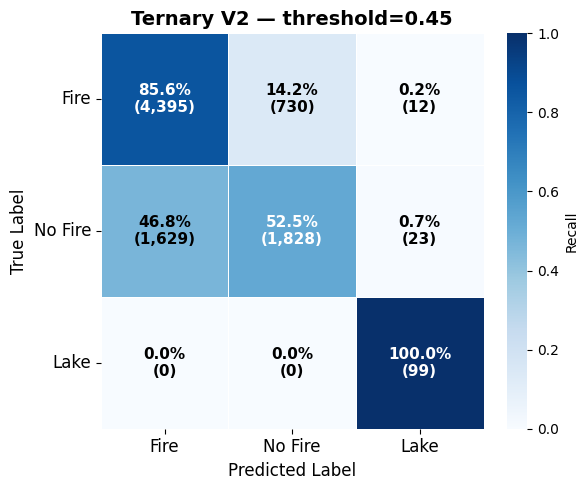

              precision    recall  f1-score   support

        Fire      0.730     0.856     0.788      5137
     No Fire      0.715     0.525     0.605      3480
        Lake      0.739     1.000     0.850        99

    accuracy                          0.725      8716
   macro avg      0.728     0.794     0.748      8716
weighted avg      0.724     0.725     0.716      8716



In [35]:
FIRE_THRESHOLD = 0.45

test_preds_thresh = ternary_predict_with_threshold(test_proba, fire_threshold=FIRE_THRESHOLD)

ml_utils.plot_confusion_matrix(
    test_true_arr, test_preds_thresh,
    class_names=["Fire", "No Fire", "Lake"],
    title=f"Ternary V2 — threshold={FIRE_THRESHOLD}"
)

print(classification_report(
    test_true_arr, test_preds_thresh,
    target_names=["Fire", "No Fire", "Lake"], digits=3
))

**comment:** The accuracy decrease however fire recall improved, but this is not enough to justify filtering window